In [2]:
print("RL Navigation Avoid Training")

RL Navigation Avoid Training


In [3]:
from __future__ import annotations
import math
import os
import numpy as np
import csv
from collections import deque
from stable_baselines3.common.callbacks import (
    BaseCallback,
    CheckpointCallback,
    CallbackList,
)
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv

from mdp.navigation.env import TwoWheelNavigationEnv, TwoWheelRobotWithoutObstacles

from mdp.obstacle_navigation.env import (
    TwoWheelRobotWithObstacles,
    TwoWheelObstacleNavigationEnv,
)

from  mdp.navigation.env import TwoWheelNavigationEnv, TwoWheelRobotWithoutObstacles

from mdp.obstacle_navigation2.env import (
    TwoWheelRobotWithObstacles2,
    TwoWheelObstacleNavigationEnv2,
)
from time import time

In [22]:
from collections import deque
import csv
import os

import numpy as np
from stable_baselines3.common.callbacks import BaseCallback


class CSVMetricsLogger(BaseCallback):
    def __init__(
        self,
        verbose: int = 0,
        rollout_window: int = 100,
        path_episodes="episodes.csv",
    ):
        super().__init__(verbose)
        self.path_episodes = path_episodes
        self.rollout_window = int(rollout_window)

        self._ep_fp = None
        self._ep_writer = None
        self._step_fp = None
        self._step_writer = None

        self._ep_return = 0.0
        self._ep_len = 0

        self._ret_window = deque(maxlen=self.rollout_window)
        self._len_window = deque(maxlen=self.rollout_window)
        self._success_window = deque(maxlen=self.rollout_window)
        self._failure_window = deque(maxlen=self.rollout_window)

    def _on_training_start(self) -> None:
        os.makedirs(os.path.dirname(self.path_episodes) or ".", exist_ok=True)
        self._ep_fp = open(self.path_episodes, "w", newline="")
        self._ep_writer = csv.DictWriter(
            self._ep_fp,
            fieldnames=[
                "timesteps",
                "episode",
                "ep_return",
                "ep_len",
                f"rollout_ep_rew_mean_{self.rollout_window}",
                f"rollout_ep_len_mean_{self.rollout_window}",
                f"rollout_avg_success_{self.rollout_window}",
                f"rollout_avg_failure_{self.rollout_window}",
                f"rollout_success_rate_{self.rollout_window}",
                "success",
                "failure",
                "final_dist",
                "path_len",
                "straight_dist",
                "path_eff",
                "reverse_ratio",
                "heading_abs_mean",
                "action_smooth_mean",
            ],
        )
        self._ep_writer.writeheader()

        self._ep_return = 0.0
        self._ep_len = 0
        self._ret_window.clear()
        self._len_window.clear()
        self._success_window.clear()
        self._failure_window.clear()
        setattr(self, "_episode_idx", 0)

    def _on_step(self) -> bool:
        rewards = self.locals.get("rewards")
        dones = self.locals.get("dones")
        infos = self.locals.get("infos")

        if rewards is None or dones is None or infos is None:
            return True

        r = float(rewards[0])
        done = bool(dones[0])
        info = infos[0]

        self._ep_return += r
        self._ep_len += 1

        if done and self._ep_writer is not None:
            ep_idx = int(getattr(self, "_episode_idx", 0))

            self._ret_window.append(float(self._ep_return))
            self._len_window.append(int(self._ep_len))

            success = float(info.get("ep_success", info.get("success", False)))
            failure = float(info.get("ep_failure", 1.0 - success))

            self._success_window.append(success)
            self._failure_window.append(failure)

            ep_rew_mean = (
                float(np.mean(self._ret_window)) if self._ret_window else float("nan")
            )
            ep_len_mean = (
                float(np.mean(self._len_window)) if self._len_window else float("nan")
            )
            avg_success = (
                float(np.mean(self._success_window))
                if self._success_window
                else float("nan")
            )
            avg_failure = (
                float(np.mean(self._failure_window))
                if self._failure_window
                else float("nan")
            )
            success_rate = avg_success

            self.logger.record("rollout/ep_rew_mean", ep_rew_mean)
            self.logger.record("rollout/ep_len_mean", ep_len_mean)
            self.logger.record("rollout/avg_success", avg_success)
            self.logger.record("rollout/avg_failure", avg_failure)
            self.logger.record("rollout/success_rate", success_rate)

            self._ep_writer.writerow(
                {
                    "timesteps": int(self.num_timesteps),
                    "episode": ep_idx,
                    "ep_return": float(self._ep_return),
                    "ep_len": int(self._ep_len),
                    f"rollout_ep_rew_mean_{self.rollout_window}": ep_rew_mean,
                    f"rollout_ep_len_mean_{self.rollout_window}": ep_len_mean,
                    f"rollout_avg_success_{self.rollout_window}": avg_success,
                    f"rollout_avg_failure_{self.rollout_window}": avg_failure,
                    f"rollout_success_rate_{self.rollout_window}": success_rate,
                    "success": int(success),
                    "failure": int(failure),
                    "final_dist": float(
                        info.get("ep_final_dist", info.get("dist_to_goal", float("nan")))
                    ),
                    "path_len": float(info.get("ep_path_len", float("nan"))),
                    "straight_dist": float(info.get("ep_straight_dist", float("nan"))),
                    "path_eff": float(info.get("ep_path_eff", float("nan"))),
                    "reverse_ratio": float(info.get("ep_reverse_ratio", float("nan"))),
                    "heading_abs_mean": float(info.get("ep_heading_abs_mean", float("nan"))),
                    "action_smooth_mean": float(
                        info.get("ep_action_smooth_mean", float("nan"))
                    ),
                }
            )

            if self.verbose > 0:
                print(
                    f"[episode {ep_idx}] "
                    f"return={self._ep_return:.3f} "
                    f"len={self._ep_len} "
                    f"success={int(success)} "
                    f"avg_success={avg_success:.3f} "
                    f"avg_failure={avg_failure:.3f} "
                    f"success_rate={success_rate:.3f}"
                )

            setattr(self, "_episode_idx", ep_idx + 1)
            self._ep_return = 0.0
            self._ep_len = 0

        return True

    def _on_training_end(self) -> None:
        if self._ep_fp is not None:
            self._ep_fp.flush()
            self._ep_fp.close()
        if self._step_fp is not None:
            self._step_fp.flush()
            self._step_fp.close()

In [5]:
def sample_goal(rng: np.random.Generator):
    r = rng.uniform(1.0, 4.5)
    a = rng.uniform(-math.pi, math.pi)
    return float(r * math.cos(a)), float(r * math.sin(a))


def sample_spawn(rng: np.random.Generator):
    r = rng.uniform(0.0, 1.0)
    a = rng.uniform(-math.pi, math.pi)
    x, y = float(r * math.cos(a)), float(r * math.sin(a))
    theta = float(rng.uniform(-math.pi, math.pi))
    return (x, y), theta

def obstacle_sampler_factory():
    def sampler(rng, start_xy, goal_xy):

        sx, sy = start_xy
        gx, gy = goal_xy

        obstacles = []
        n_obs = rng.integers(2, 6)

        path = np.array([gx - sx, gy - sy])
        path_len = np.linalg.norm(path)

        if path_len < 1e-6:
            return obstacles

        path_dir = path / path_len
        perp = np.array([-path_dir[1], path_dir[0]])

        for _ in range(n_obs):

            r = rng.uniform(0.2, 0.5)

            if rng.random() < 0.8:

                t = rng.uniform(0.2, 0.8)
                base = np.array([sx, sy]) + path * t

                offset = perp * rng.uniform(-0.8, 0.8)

                ox, oy = base + offset

            else:

                ox = rng.uniform(-4.5, 4.5)
                oy = rng.uniform(-4.5, 4.5)

            if np.hypot(ox - sx, oy - sy) < 0.7:
                continue

            if np.hypot(ox - gx, oy - gy) < 0.7:
                continue

            obstacles.append((float(ox), float(oy), float(r)))

        return obstacles

    return sampler

path_obstacle_sampler = obstacle_sampler_factory()




## Train (Navigation only)

In [ ]:
def make_navigation_env(robot: None, seed: int | None = None):
    def robot_factory():
        if robot:
            return robot
        return TwoWheelRobotWithoutObstacles(
            wheel_distance=0.3,
        )

    return TwoWheelNavigationEnv(
        robot_factory=robot_factory,
        wheel_speed_limit=0.6,
        dt=0.1,
        max_steps=250,
        goal_radius=0.2,
        spawn_sampler=sample_spawn,
        goal_xy_sampler=sample_goal,
        arena_radius=6.0,
        obs_norm_radius=6.0,
        effort_penalty=0.01,
        spin_penalty=0.002,
        stall_penalty=0.05,
        stall_window=12,
        stall_tol=1e-3,
        success_bonus=10.0,
        oob_penalty=2.0,
        allow_reverse=False,
        render_enabled=not False,
        seed=seed,
        render_path="training_outputs/navigation/output.png",
    )

In [8]:
env = DummyVecEnv([lambda: make_navigation_env(seed=0)])

model = SAC(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    buffer_size=300_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=1,
    gradient_steps=1,
    verbose=1,
)

checkpoint_cb = CheckpointCallback(
    save_freq=10_000,
    save_path="training_outputs/navigation/checkpoints",
    name_prefix="",
    save_replay_buffer=True,
    save_vecnormalize=True,
)

csv__metrics_cb = CSVMetricsLogger(
    path_episodes="training_outputs/navigation/episodes.csv",
)

model.learn(
    total_timesteps=100_000,
    callback=CallbackList(
        [checkpoint_cb, csv__metrics_cb],
    ),
)
model.save("training_outputs/navigation/model.zip")

Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 213      |
|    ep_rew_mean     | -17.2    |
| time/              |          |
|    episodes        | 4        |
|    fps             | 115      |
|    time_elapsed    | 7        |
|    total_timesteps | 851      |
| train/             |          |
|    actor_loss      | -5.55    |
|    critic_loss     | 0.0687   |
|    ent_coef        | 0.799    |
|    ent_coef_loss   | -0.757   |
|    learning_rate   | 0.0003   |
|    n_updates       | 750      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 225      |
|    ep_rew_mean     | -16.3    |
| time/              |          |
|    episodes        | 8        |
|    fps             | 117      |
|    time_elapsed    | 15       |
|    total_timesteps | 1798     |
| train/             |          |
|    actor_loss      | -8.52    |
|    critic_loss     | 0.0138  

D=>  3.000138201373331
-0.1741528150935968
D=>  2.99568652921162
-0.34206810531516874
D=>  2.984785564510857
-0.49713225848972803
D=>  2.9718280943688127
-0.6558302895476422
D=>  2.954096992244283
-0.8427549948294959
D=>  2.929319432232743
-0.9902302076419196
D=>  2.904069000833189
-1.1734938522179923
D=>  2.8715888147478585
-1.3231656501690547
D=>  2.827798179900725
-1.3491289963324866
D=>  2.77431790573254
-1.3605994532505672
D=>  2.7181806387055247
-1.360346570611
D=>  2.6732067765395047
-1.42140631377697
D=>  2.6276987676756436
-1.369109645485878
D=>  2.576344851546665
-1.3943924556175868
D=>  2.5232424701203042
-1.3971564422051113
D=>  2.4862740213105643
-1.4400789588689804
D=>  2.4322269514778703
-1.459435408314069
D=>  2.3757927058893222
-1.4704115241765976
D=>  2.3273732354985115
-1.5162504762411118
D=>  2.273218245084043
-1.5355893621842067
D=>  2.216064658402956
-1.5282731701930365
D=>  2.161387498786928
-1.5191511362791064
D=>  2.1108797950815914
-1.4706157197554908
D=>  2.0

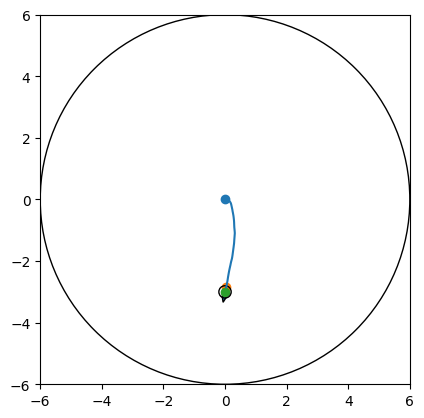

In [4]:
from time import time


r = TwoWheelRobotWithoutObstacles(
    wheel_distance=0.3,
)

an_env = make_navigation_env(robot=r)

model = SAC.load("training_outputs/navigation/model.zip")
obs, _ = an_env.reset(
    goal_xy=(0, -3),
    robot_pos=(0, 0, 0),
    reset_robot=True,
    seed=int(time()),
)

while True:
    action, _ = model.predict(obs)

    obs, _, terminated, truncated, _ = an_env.step(action)
    x, y, t = r.state()
    if terminated or truncated:
        break

print("Done")

## Navigation + Obstacle Avoidance

In [4]:
def make_robot_with_obstacles():
    return TwoWheelRobotWithObstacles(
        wheel_distance=0.3,
        sonar_max_range=2.0,
    )



In [5]:
class TrainingEnv(TwoWheelObstacleNavigationEnv):
    def reset(self, *args, **kwargs):

        obs, info = super().reset(*args, **kwargs)

        sx, sy = self._ep_start_xy
        gx, gy = self.goal

        self.obstacles = path_obstacle_sampler(self.np_random, (sx, sy), (gx, gy))

        self.robot.obstacles = self.obstacles

        return obs, info
        

In [57]:
env = DummyVecEnv(
    [
        lambda: TrainingEnv(
            robot_factory=make_robot_with_obstacles,
            spawn_sampler=sample_spawn,
            goal_xy_sampler=sample_goal,
            wheel_speed_limit=0.6,
            max_steps=500,
            obs_norm_radius=6.0,
            arena_radius=6.0,
            safe_distance=0.25,
            collision_penalty=8.0,
            obstacle_penalty=0.4,
            render_enabled=False,
            allow_reverse=True,
            render_path="training_outputs/obstacle_navigation/output.png",

        )
    ]
)

checkpoint_cb = CheckpointCallback(
    save_freq=10_000,
    save_path="training_outputs/obstacle_navigation/checkpoints",
    name_prefix="",
)

csv__metrics_cb = CSVMetricsLogger(
    path_episodes="training_outputs/obstacle_navigation/episodes.csv",
)


model = SAC("MlpPolicy", env, verbose=1)

model.learn(
    total_timesteps=2_000_000,
    callback=CallbackList(
        [checkpoint_cb, csv__metrics_cb],
    ),
)

model.save("training_outputs/obstacle_navigation/model.zip")

Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | -14.6    |
| time/              |          |
|    episodes        | 4        |
|    fps             | 99       |
|    time_elapsed    | 20       |
|    total_timesteps | 2000     |
| train/             |          |
|    actor_loss      | -9.33    |
|    critic_loss     | 0.0103   |
|    ent_coef        | 0.566    |
|    ent_coef_loss   | -1.92    |
|    learning_rate   | 0.0003   |
|    n_updates       | 1899     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 470      |
|    ep_rew_mean     | -17.5    |
| time/              |          |
|    episodes        | 8        |
|    fps             | 101      |
|    time_elapsed    | 36       |
|    total_timesteps | 3764     |
| train/             |          |
|    actor_loss      | -12.5    |
|    critic_loss     | 0.0173  

KeyboardInterrupt: 

Done


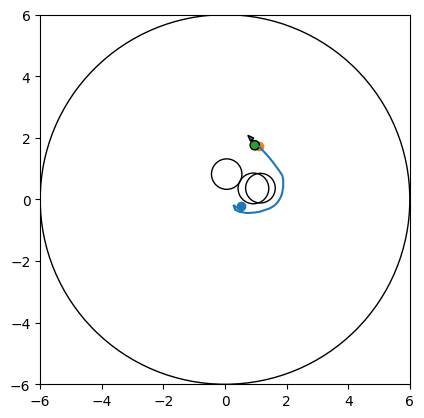

In [19]:
from time import time


r = TwoWheelRobotWithObstacles(
        wheel_distance=0.3,
        sonar_max_range=2.0,
    )

an_env = TrainingEnv(
            robot_factory=lambda *_,**__:r,
            spawn_sampler=sample_spawn,
            goal_xy_sampler=sample_goal,
            obs_norm_radius=6.0,
            arena_radius=6.0,
            render_enabled=True,
            allow_reverse=True,
            render_path="training_outputs/obstacle_navigation/output.png",
            #
            goal_radius=0.15,
            max_steps=9999,
            safe_distance=0.1,

        )

model = SAC.load("training_outputs/obstacle_navigation/checkpoints/_1680000_steps.zip")
obs, _ = an_env.reset(
    # goal_xy=(0, -3),
    # robot_pos=(0, 0, 0),
    reset_robot=True,
    seed=int(time()),
)

while True:
    action, _ = model.predict(obs)
    # action=(action/(0.02*10))*0.6
    obs, _, terminated, truncated, _ = an_env.step(action)
    x, y, t,*_ = r.state()
    if terminated or truncated:
        break

print("Done")

## Obstacle 2

In [6]:
def make_robot2():
    return TwoWheelRobotWithObstacles2(
        wheel_distance=0.32,
        lookahead=2,
        robot_diameter=0.36,
        lidar_fov_deg=180.0,
        lidar_num_beams=181,
        corridor_margin=0.03,
        front_width_ratio=0.5,
    )

In [7]:
class TrainingEnv2(TwoWheelObstacleNavigationEnv2):
    def reset(self, *args, **kwargs):

        obs, info = super().reset(*args, **kwargs)

        sx, sy = self._ep_start_xy
        gx, gy = self.goal

        self.obstacles = path_obstacle_sampler(self.np_random, (sx, sy), (gx, gy))

        self.robot.obstacles = self.obstacles

        return obs, info

In [20]:
from collections import deque
import numpy as np
from stable_baselines3.common.callbacks import BaseCallback


class SuccessFailureLogger(BaseCallback):
    def __init__(self, window_size: int = 100, verbose: int = 1):
        super().__init__(verbose)
        self.window_size = int(window_size)
        self.successes = deque(maxlen=self.window_size)
        self.failures = deque(maxlen=self.window_size)

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])

        for info in infos:
            if "ep_success" in info and "ep_failure" in info:
                self.successes.append(float(info["ep_success"]))
                self.failures.append(float(info["ep_failure"]))

        if len(self.successes) > 0:
            avg_success = float(np.mean(self.successes))
            avg_failure = float(np.mean(self.failures))
            success_rate = avg_success

            self.logger.record("rollout/avg_success", avg_success)
            self.logger.record("rollout/avg_failure", avg_failure)
            self.logger.record("rollout/success_rate", success_rate)

            if self.verbose > 0 and self.num_timesteps % 1000 == 0:
                print(
                    f"timesteps={self.num_timesteps} "
                    f"avg_success={avg_success:.3f} "
                    f"avg_failure={avg_failure:.3f} "
                    f"success_rate={success_rate:.3f}"
                )

        return True

Using cpu device
---------------------------------
| rollout/           |          |
|    avg_failure     | 1        |
|    avg_success     | 0        |
|    ep_len_mean     | 222      |
|    ep_rew_mean     | -18.4    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 4        |
|    fps             | 12       |
|    time_elapsed    | 69       |
|    total_timesteps | 887      |
| train/             |          |
|    actor_loss      | -5.46    |
|    critic_loss     | 0.0275   |
|    ent_coef        | 0.79     |
|    ent_coef_loss   | -0.79    |
|    learning_rate   | 0.0003   |
|    n_updates       | 786      |
---------------------------------


KeyboardInterrupt: 

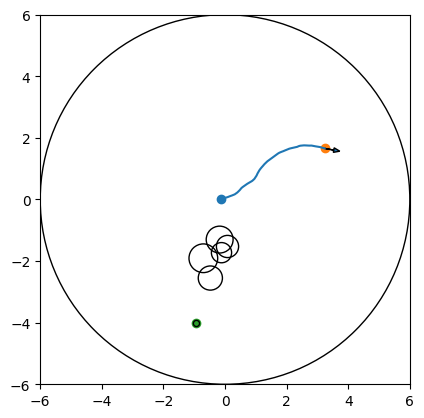

In [23]:
env = DummyVecEnv(
    [
        lambda: TrainingEnv2(
            robot_factory=make_robot2,
            spawn_sampler=sample_spawn,
            goal_xy_sampler=sample_goal,
            dt=0.1,
            wheel_speed_limit=0.4,
            max_steps=300,
            obs_norm_radius=6.0,
            arena_radius=6.0,
            safe_distance=0.25,
            collision_penalty=8.0,
            obstacle_penalty=0.4,
            render_enabled=not False,
            allow_reverse=False,
            render_path="training_outputs/obstacle_navigation2/output.png",
        )
    ]
)

checkpoint_cb = CheckpointCallback(
    save_freq=10_000,
    save_path="training_outputs/obstacle_navigation2/checkpoints",
    name_prefix="",
)

csv__metrics_cb = CSVMetricsLogger(
    path_episodes="training_outputs/obstacle_navigation2/episodes.csv",
)

success_logger = SuccessFailureLogger(window_size=100)

model = SAC("MlpPolicy", env, verbose=1)

model.learn(
    total_timesteps=2_000_000,
    callback=CallbackList(
        [checkpoint_cb, success_logger, csv__metrics_cb],
    ),
)

model.save("training_outputs/obstacle_navigation2/model.zip")